# Train/test-ratio evaluation across three random seeds

This notebook evaluates how the models from Section 2.3 of `02_main_cv_ablation.ipynb` change as the active-energy training fraction increases.  Every train/test ratio is evaluated with three random seeds, and the results report mean ± standard deviation for diene distortion, ene distortion, interaction energy, and activation free energy.

The full ΔGrxn-assisted model and the three ablations are included by default.  No cells are executed in the delivered notebook.


In [1]:
from pathlib import Path
import os
import sys

def repository_root(start):
    for path in (start, *start.parents):
        if (path / "Code" / "model_train.py").is_file():
            return path
    raise FileNotFoundError("Start Jupyter inside the CycloAddGenerator repository.")

REPO_ROOT = repository_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "03_modeling"))
DATA_DIR = REPO_ROOT / "Data" / "DFT_Result"
DESCRIPTOR_MAP = REPO_ROOT / "Data" / "Descriptors" / "Descriptors_.pkl"

## 1. Imports and experiment configuration

`TRAIN_FRACTIONS` is the fraction assigned to training; the remaining reactions form the test set.  Set `MODEL_VARIANTS` to a subset if only the main model is required.


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

from Code import model_train

warnings.filterwarnings("ignore")

SEEDS = [0, 1, 2]
TRAIN_FRACTIONS = [0.2, 0.4, 0.6, 0.8]
PHYSORG_FEATURE_COUNT = 48

ALL_MODEL_VARIANTS = [
    "PhysOrg",
    "PhysOrg + SVO",
    "PhysOrg + SVO + predicted ΔGrxn (Active_Energy only)",
    "PhysOrg + SVO + predicted ΔGrxn (Rxn main model)",
]
MODEL_VARIANTS = ALL_MODEL_VARIANTS.copy()

CATBOOST_PARAMS = dict(
    task_type="CPU",
    iterations=10_000,
    learning_rate=0.01,
    depth=6,
    verbose=0,
)

DATA_DIR = REPO_ROOT / "Data" / "DFT_Result"
DATA_GA_FILE = DATA_DIR / "Active_Energy.csv"
DATA_G_FILE = DATA_DIR / "Rxn.csv"
QM_MAP = DESCRIPTOR_MAP
for required_path in (DATA_GA_FILE, DATA_G_FILE, QM_MAP):
    if not required_path.exists():
        raise FileNotFoundError(f"Required input is missing: {required_path.resolve()}")

## 2. Load aligned descriptors and targets


In [3]:
def load_aligned_data(csv_path, descriptor_map):
    raw_df = pd.read_csv(csv_path).reset_index(drop=True)
    features, retained_rows = model_train.read_df(raw_df, str(descriptor_map))
    retained_rows = np.asarray(retained_rows, dtype=int)
    aligned_df = raw_df.iloc[retained_rows].reset_index(drop=True)
    if len(aligned_df) != features.shape[0]:
        raise RuntimeError("Descriptor matrix and DataFrame are not aligned.")
    return aligned_df, features


data_Ga, X_Ga = load_aligned_data(DATA_GA_FILE, QM_MAP)
data_G, X_G = load_aligned_data(DATA_G_FILE, QM_MAP)
required_ga_columns = [
    "Diene_Index", "Ene_Index", "Structure_id", "deltaG",
    "Diene_Distort", "Ene_Distort", "Interaction", "deltaGa(Solvent)",
]
required_g_columns = ["Diene_Index", "Ene_Index", "Structure_id", "Interaction", "deltaG"]
for column in required_ga_columns:
    if column not in data_Ga.columns:
        raise KeyError(f"Active_Energy.csv is missing: {column}")
for column in required_g_columns:
    if column not in data_G.columns:
        raise KeyError(f"Rxn.csv is missing: {column}")
if X_Ga.shape[1] < PHYSORG_FEATURE_COUNT:
    raise ValueError("X_Ga has fewer columns than the PhysOrg feature block.")

TARGETS = {
    "Diene distortion": data_Ga["Diene_Distort"].to_numpy(),
    "Ene distortion": data_Ga["Ene_Distort"].to_numpy(),
    "Interaction": data_Ga["Interaction"].to_numpy(),
    "Activation free energy (ΔG‡)": data_Ga["deltaGa(Solvent)"].to_numpy(),
}
Y_DG_GA = data_Ga["deltaG"].to_numpy()
Y_DG_ALL = data_G["deltaG"].to_numpy()
print(f"Active-energy reactions: {len(data_Ga):,}; Rxn reactions: {len(data_G):,}")

100%|██████████| 50161/50161 [00:06<00:00, 7401.46it/s]


Active-energy reactions: 8,273; Rxn reactions: 50,161


## 3. Split and model helpers

`broad_delta_g_training_ids` matches the full-model practice in Section 2.3: the exact active-energy reactions in the holdout set are excluded from `Rxn.csv` when training the broad ΔGrxn model.


In [4]:
def reaction_key_set(frame):
    return set(zip(
        frame["Diene_Index"].astype(int),
        frame["Ene_Index"].astype(int),
        frame["Structure_id"].astype(int),
    ))


def broad_delta_g_training_ids(test_ids):
    held_out_keys = reaction_key_set(data_Ga.iloc[test_ids])
    broad_keys = list(zip(
        data_G["Diene_Index"].astype(int),
        data_G["Ene_Index"].astype(int),
        data_G["Structure_id"].astype(int),
    ))
    keep_mask = data_G["Interaction"].isna().to_numpy() | np.array(
        [key not in held_out_keys for key in broad_keys], dtype=bool
    )
    train_ids = np.flatnonzero(keep_mask)
    if len(train_ids) == 0:
        raise ValueError("No broad ΔGrxn training reactions remain.")
    return train_ids


def metric_values(y_true, y_pred):
    return {
        "r2": model_train.r2_score(y_true, y_pred),
        "mae": model_train.mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(model_train.mean_squared_error(y_true, y_pred))),
    }


def evaluate_split(train_ids, test_ids, train_fraction, seed):
    records = []
    feature_sets = {
        "PhysOrg": X_Ga[:, :PHYSORG_FEATURE_COUNT],
        "PhysOrg + SVO": X_Ga,
    }

    active_pred_dg = None
    if "PhysOrg + SVO + predicted ΔGrxn (Active_Energy only)" in MODEL_VARIANTS:
        active_dg_model = CatBoostRegressor(random_seed=seed, **CATBOOST_PARAMS)
        active_dg_model.fit(X_Ga[train_ids], Y_DG_GA[train_ids])
        active_pred_dg = active_dg_model.predict(X_Ga)
        feature_sets["PhysOrg + SVO + predicted ΔGrxn (Active_Energy only)"] = np.column_stack(
            [X_Ga, active_pred_dg]
        )

    broad_pred_dg = None
    if "PhysOrg + SVO + predicted ΔGrxn (Rxn main model)" in MODEL_VARIANTS:
        broad_train_ids = broad_delta_g_training_ids(test_ids)
        broad_dg_model = CatBoostRegressor(random_seed=seed, **CATBOOST_PARAMS)
        broad_dg_model.fit(X_G[broad_train_ids], Y_DG_ALL[broad_train_ids])
        broad_pred_dg = broad_dg_model.predict(X_Ga)
        feature_sets["PhysOrg + SVO + predicted ΔGrxn (Rxn main model)"] = np.column_stack(
            [X_Ga, broad_pred_dg]
        )
    else:
        broad_train_ids = np.array([], dtype=int)

    for model_name in MODEL_VARIANTS:
        if model_name in {"PhysOrg", "PhysOrg + SVO"}:
            dg_model = CatBoostRegressor(random_seed=seed, **CATBOOST_PARAMS)
            dg_model.fit(feature_sets[model_name][train_ids], Y_DG_GA[train_ids])
            dg_prediction = dg_model.predict(feature_sets[model_name][test_ids])
        elif model_name.endswith("(Active_Energy only)"):
            dg_prediction = active_pred_dg[test_ids]
        else:
            dg_prediction = broad_pred_dg[test_ids]
        records.append({
            "seed": seed,
            "train_fraction": train_fraction,
            "test_fraction": 1 - train_fraction,
            "n_train": len(train_ids),
            "n_test": len(test_ids),
            "n_broad_deltaG_train": len(broad_train_ids),
            "model": model_name,
            "target": "Reaction free energy (ΔGrxn)",
            **metric_values(Y_DG_GA[test_ids], dg_prediction),
        })
        for target_name, y_target in TARGETS.items():
            model = CatBoostRegressor(random_seed=seed, **CATBOOST_PARAMS)
            model.fit(feature_sets[model_name][train_ids], y_target[train_ids])
            y_pred = model.predict(feature_sets[model_name][test_ids])
            records.append({
                "seed": seed,
                "train_fraction": train_fraction,
                "test_fraction": 1 - train_fraction,
                "n_train": len(train_ids),
                "n_test": len(test_ids),
                "n_broad_deltaG_train": len(broad_train_ids),
                "model": model_name,
                "target": target_name,
                **metric_values(y_target[test_ids], y_pred),
            })
    return records

## 4. Evaluate every ratio with three seeds

This is the only training cell.  Each seed is sampled independently at each training fraction.


In [5]:
split_rows = []
all_records = []
all_ids = np.arange(len(data_Ga))
for train_fraction in TRAIN_FRACTIONS:
    for seed in SEEDS:
        train_ids, test_ids = train_test_split(
            all_ids,
            train_size=train_fraction,
            random_state=seed,
            shuffle=True,
        )
        train_ids = np.sort(train_ids)
        test_ids = np.sort(test_ids)
        split_rows.append({
            "seed": seed,
            "train_fraction": train_fraction,
            "test_fraction": 1 - train_fraction,
            "n_train": len(train_ids),
            "n_test": len(test_ids),
        })
        all_records.extend(evaluate_split(train_ids, test_ids, train_fraction, seed))
        print(f"Finished train fraction={train_fraction:.0%}, seed={seed}")

split_summary = pd.DataFrame(split_rows)
ratio_seed_results = pd.DataFrame(all_records)
assert ratio_seed_results.groupby(["seed", "train_fraction", "model", "target"]).size().eq(1).all()
display(split_summary)
ratio_seed_results.head()

Finished train fraction=20%, seed=0
Finished train fraction=20%, seed=1
Finished train fraction=20%, seed=2
Finished train fraction=40%, seed=0
Finished train fraction=40%, seed=1
Finished train fraction=40%, seed=2
Finished train fraction=60%, seed=0
Finished train fraction=60%, seed=1
Finished train fraction=60%, seed=2
Finished train fraction=80%, seed=0
Finished train fraction=80%, seed=1
Finished train fraction=80%, seed=2


,seed,train_fraction,test_fraction,n_train,n_test
0,0,0.2,0.8,1654,6619
1,1,0.2,0.8,1654,6619
2,2,0.2,0.8,1654,6619
3,0,0.4,0.6,3309,4964
4,1,0.4,0.6,3309,4964
5,2,0.4,0.6,3309,4964
6,0,0.6,0.4,4963,3310
7,1,0.6,0.4,4963,3310
8,2,0.6,0.4,4963,3310
9,0,0.8,0.2,6618,1655


,seed,train_fraction,test_fraction,n_train,n_test,n_broad_deltaG_train,model,target,r2,mae,rmse
0,0,0.2,0.8,1654,6619,43542,PhysOrg,Reaction free energy (ΔGrxn),0.884175,2.756151,4.004453
1,0,0.2,0.8,1654,6619,43542,PhysOrg,Diene distortion,0.870311,1.596325,2.203798
2,0,0.2,0.8,1654,6619,43542,PhysOrg,Ene distortion,0.642695,1.672845,2.271528
3,0,0.2,0.8,1654,6619,43542,PhysOrg,Interaction,0.647365,2.042051,2.866437
4,0,0.2,0.8,1654,6619,43542,PhysOrg,Activation free energy (ΔG‡),0.799365,2.544585,3.505851


## 5. Aggregate model performance across seeds


In [6]:
ratio_summary = (
    ratio_seed_results
    .groupby(["train_fraction", "test_fraction", "model", "target"], as_index=False)
    .agg(
        seeds=("seed", "nunique"),
        n_train=("n_train", "mean"),
        n_test=("n_test", "mean"),
        r2_mean=("r2", "mean"), r2_std=("r2", "std"),
        mae_mean=("mae", "mean"), mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
    )
    .sort_values(["target", "model", "train_fraction"])
    .reset_index(drop=True)
)
display(ratio_summary)

main_model_name = "PhysOrg + SVO + predicted ΔGrxn (Rxn main model)"
main_model_ratio_summary = ratio_summary.query("model == @main_model_name").copy()
display(main_model_ratio_summary)

,train_fraction,test_fraction,model,target,seeds,n_train,n_test,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,0.2,0.8,PhysOrg,Activation free energy (ΔG‡),3,1654.0,6619.0,0.801789,0.008585,2.519670,0.041287,3.474709,0.079508
1,0.4,0.6,PhysOrg,Activation free energy (ΔG‡),3,3309.0,4964.0,0.854405,0.001524,2.157383,0.014616,2.974390,0.009483
2,0.6,0.4,PhysOrg,Activation free energy (ΔG‡),3,4963.0,3310.0,0.875473,0.002604,1.976114,0.006978,2.736398,0.010343
3,0.8,0.2,PhysOrg,Activation free energy (ΔG‡),3,6618.0,1655.0,0.893014,0.012163,1.853229,0.069164,2.551858,0.121342
4,0.2,0.8,PhysOrg + SVO,Activation free energy (ΔG‡),3,1654.0,6619.0,0.821530,0.007463,2.379191,0.040554,3.297155,0.071025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.8,0.2,PhysOrg + SVO + predicted ΔGrxn (Active_Energy...,Reaction free energy (ΔGrxn),3,6618.0,1655.0,0.955788,0.000767,1.696252,0.023377,2.457384,0.004293
76,0.2,0.8,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Reaction free energy (ΔGrxn),3,1654.0,6619.0,0.910207,0.002331,2.595147,0.024009,3.533909,0.035672
77,0.4,0.6,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Reaction free energy (ΔGrxn),3,3309.0,4964.0,0.927403,0.002113,2.356714,0.044565,3.178548,0.040088
78,0.6,0.4,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Reaction free energy (ΔGrxn),3,4963.0,3310.0,0.936384,0.002051,2.198890,0.021395,2.989949,0.033492


,train_fraction,test_fraction,model,target,seeds,n_train,n_test,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
12,0.2,0.8,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Activation free energy (ΔG‡),3,1654.0,6619.0,0.844780,0.007866,2.214507,0.036986,3.074632,0.075514
13,0.4,0.6,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Activation free energy (ΔG‡),3,3309.0,4964.0,0.891286,0.003676,1.863537,0.024616,2.570027,0.046469
14,0.6,0.4,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Activation free energy (ΔG‡),3,4963.0,3310.0,0.907114,0.004579,1.700342,0.020323,2.362943,0.054392
15,0.8,0.2,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Activation free energy (ΔG‡),3,6618.0,1655.0,0.920252,0.011052,1.584904,0.045056,2.201742,0.124724
28,0.2,0.8,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Diene distortion,3,1654.0,6619.0,0.895210,0.001547,1.417854,0.012558,1.975735,0.008391
29,0.4,0.6,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Diene distortion,3,3309.0,4964.0,0.921354,0.002186,1.223543,0.008472,1.713980,0.020647
30,0.6,0.4,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Diene distortion,3,4963.0,3310.0,0.931058,0.001159,1.139391,0.008176,1.595896,0.002567
31,0.8,0.2,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Diene distortion,3,6618.0,1655.0,0.938773,0.002421,1.078997,0.020037,1.506105,0.024447
44,0.2,0.8,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Ene distortion,3,1654.0,6619.0,0.715787,0.007503,1.483091,0.003938,2.022028,0.025055
45,0.4,0.6,PhysOrg + SVO + predicted ΔGrxn (Rxn main model),Ene distortion,3,3309.0,4964.0,0.771864,0.006632,1.315922,0.005690,1.818669,0.023103


## 6. Visual comparison

The lines show the mean over the three seeds; shaded bands show ± one standard deviation.


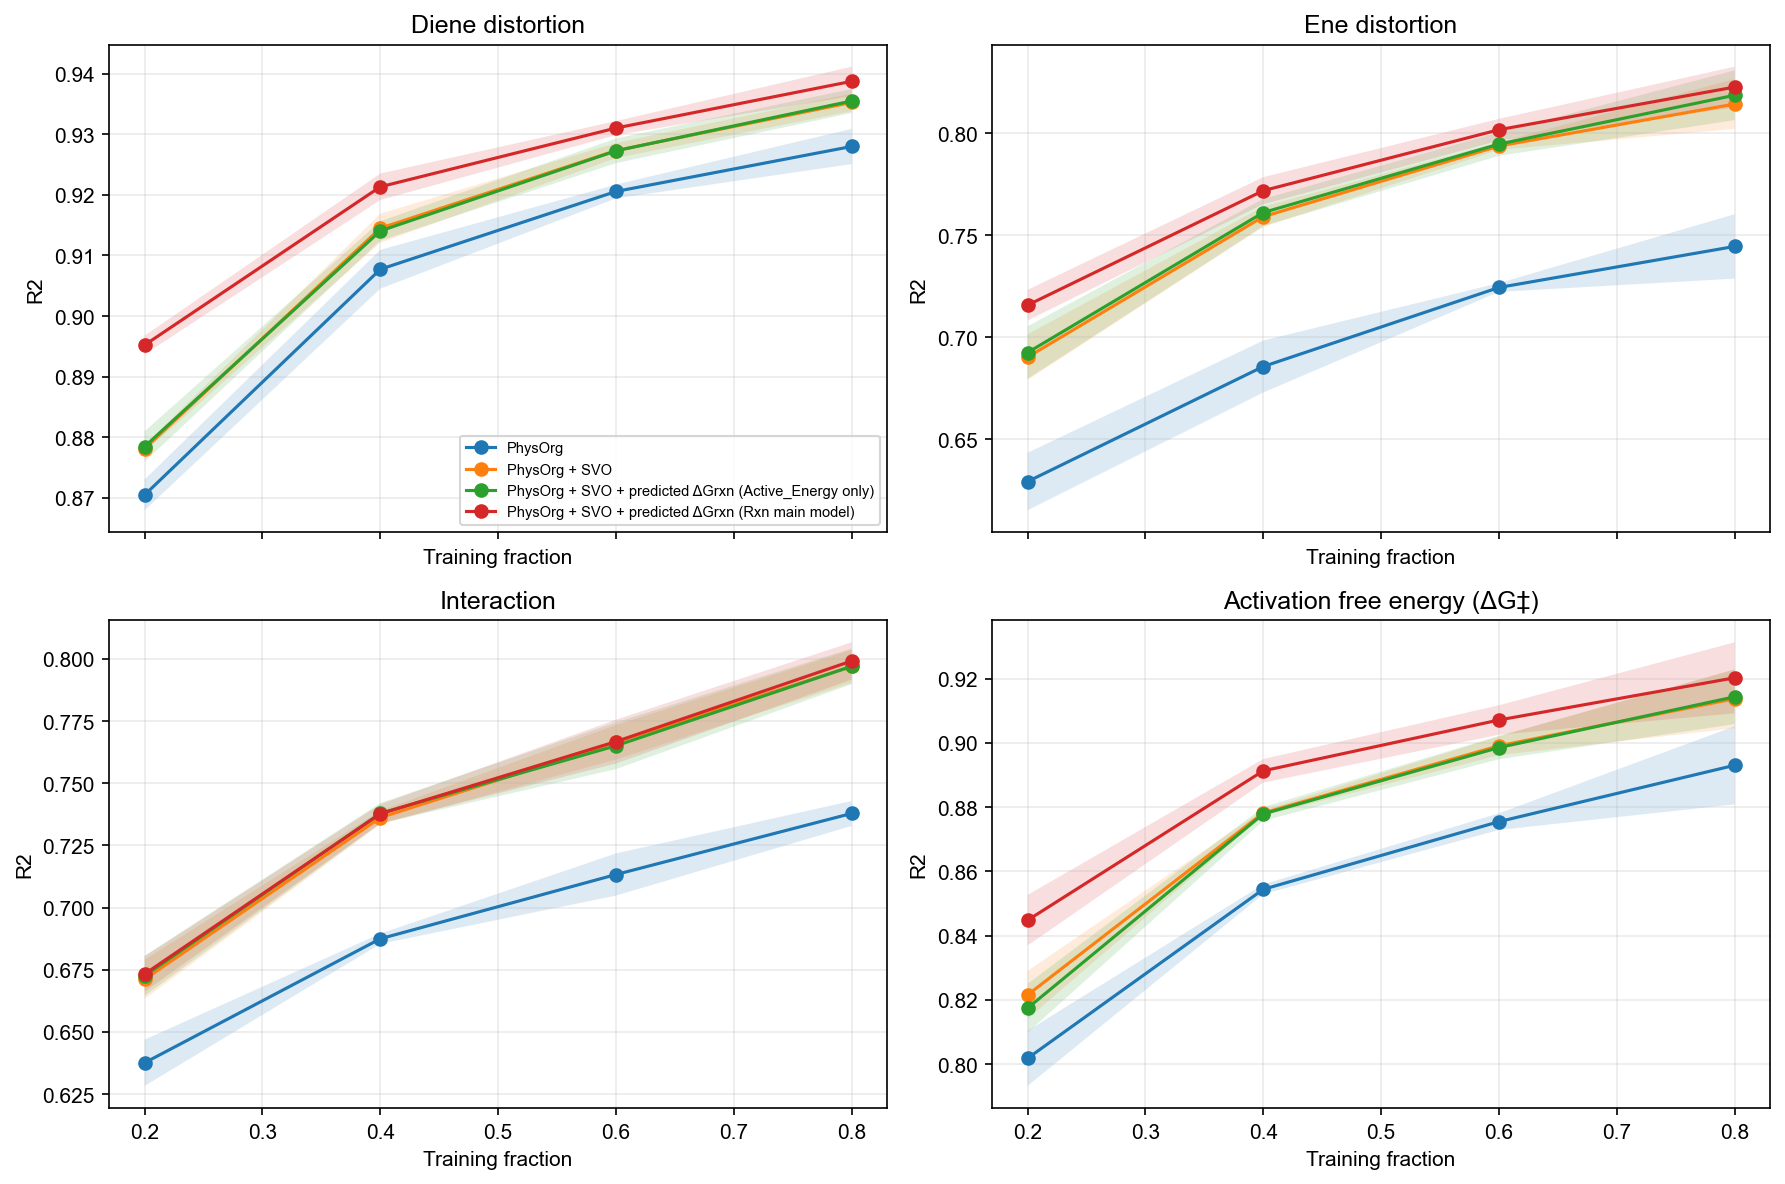

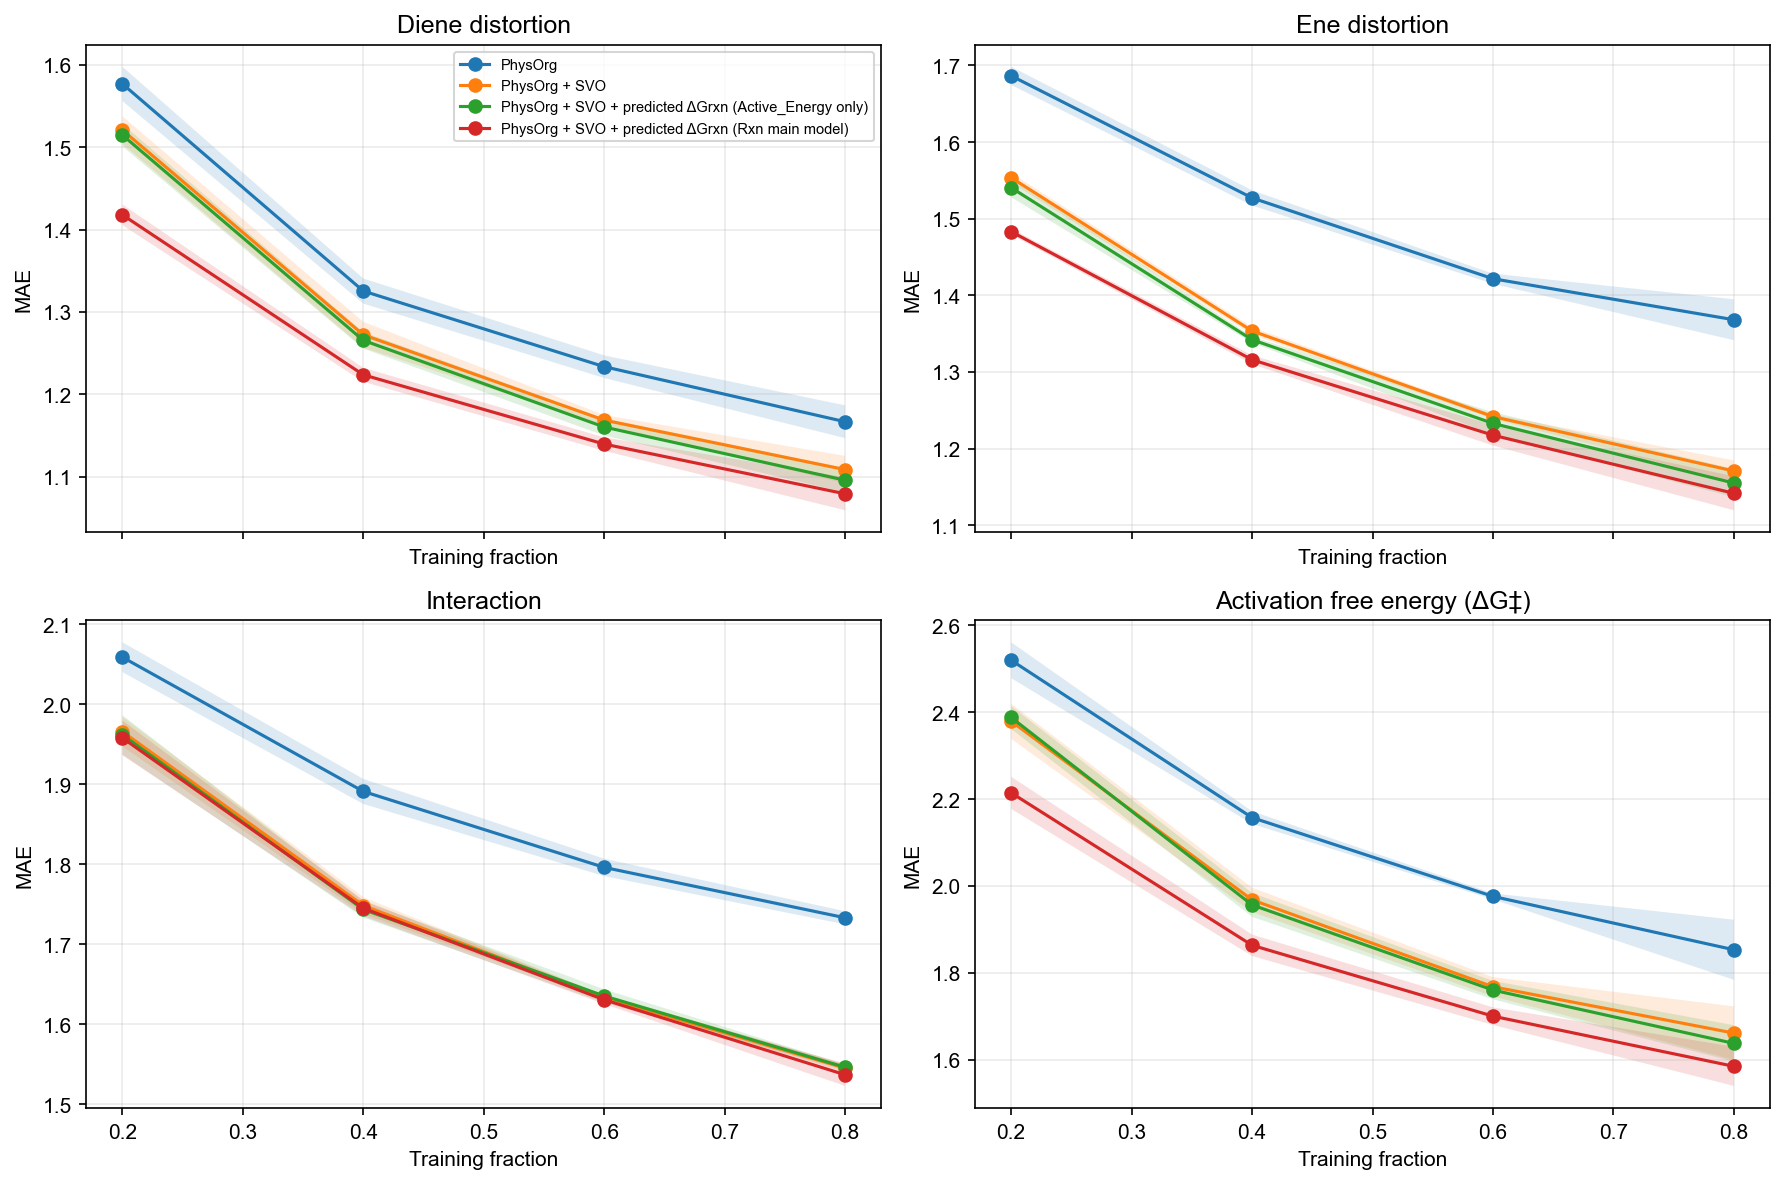

In [7]:
for metric in ["r2", "mae"]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150, sharex=True)
    for axis, target_name in zip(axes.ravel(), TARGETS):
        subset = ratio_summary.query("target == @target_name")
        for model_name in MODEL_VARIANTS:
            values = subset.query("model == @model_name").sort_values("train_fraction")
            axis.plot(values["train_fraction"], values[f"{metric}_mean"], marker="o", label=model_name)
            axis.fill_between(
                values["train_fraction"],
                values[f"{metric}_mean"] - values[f"{metric}_std"].fillna(0),
                values[f"{metric}_mean"] + values[f"{metric}_std"].fillna(0),
                alpha=0.15,
            )
        axis.set(title=target_name, xlabel="Training fraction", ylabel=metric.upper())
        axis.grid(alpha=0.25)
    axes[0, 0].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

# Optional explicit exports (disabled by default).
# ratio_seed_results.to_csv("Data/DFT_Result/ratio_seed_results.csv", index=False)
# ratio_summary.to_csv("Data/DFT_Result/ratio_seed_summary.csv", index=False)